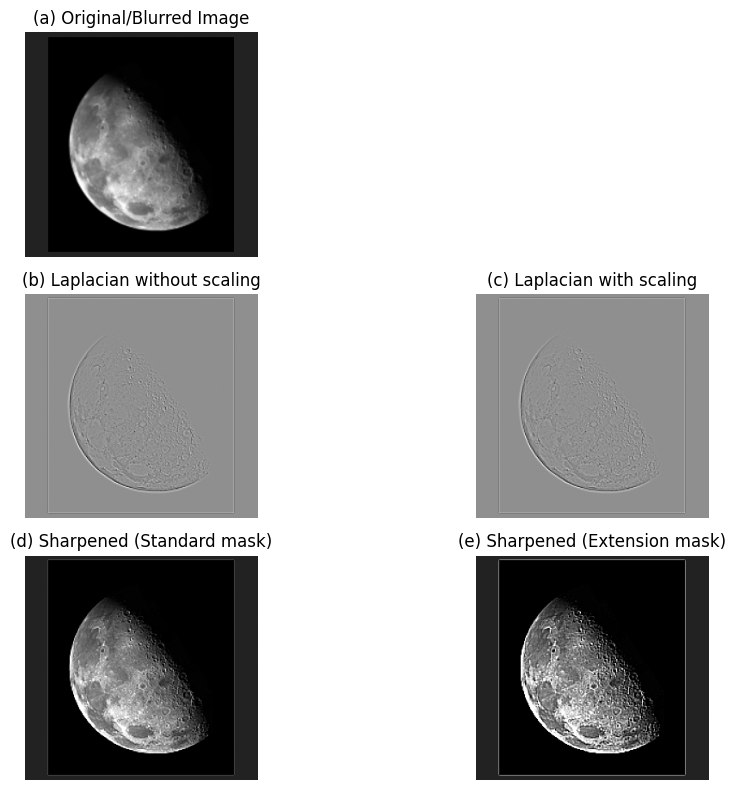

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc ảnh gốc (ảnh xám)
# Đổi 'moon.tif' thành đường dẫn ảnh của em
img = cv2.imread('/content/mattrang.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Không tìm thấy file ảnh. Vui lòng kiểm tra lại đường dẫn!")

# Chuyển đổi sang float64 để tránh lỗi tràn số khi tính đạo hàm (có giá trị âm)
img_float = img.astype(np.float64)

# 2. Định nghĩa các kernel Laplacian (hệ số tâm âm)
kernel_standard = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
], dtype=np.float64)

kernel_extension = np.array([
    [1,  1, 1],
    [1, -8, 1],
    [1,  1, 1]
], dtype=np.float64)

# (b) Laplacian không scaling (chưa chuẩn hóa về 0-255, chứa giá trị âm)
laplacian_b = cv2.filter2D(img_float, -1, kernel_standard)

# (c) Laplacian có scaling (chuẩn hóa giá trị về [0, 255] để hiển thị)
laplacian_c = laplacian_b - laplacian_b.min()
laplacian_c = (laplacian_c / laplacian_c.max()) * 255.0

# (d) Làm sắc nét ảnh dùng kernel chuẩn: g = f - Laplacian
sharpened_d = img_float - laplacian_b
sharpened_d = np.clip(sharpened_d, 0, 255) # Giới hạn dải giá trị [0, 255]

# (e) Làm sắc nét ảnh dùng kernel mở rộng (Extension mask)
laplacian_e_raw = cv2.filter2D(img_float, -1, kernel_extension)
sharpened_e = img_float - laplacian_e_raw
sharpened_e = np.clip(sharpened_e, 0, 255)

# 3. Hiển thị kết quả tương tự layout trên slide
plt.figure(figsize=(10, 8))

plt.subplot(3, 2, 1)
plt.imshow(img, cmap='gray')
plt.title('(a) Original/Blurred Image')
plt.axis('off')

plt.subplot(3, 2, 3)
plt.imshow(laplacian_b, cmap='gray')
plt.title('(b) Laplacian without scaling')
plt.axis('off')

plt.subplot(3, 2, 4)
plt.imshow(laplacian_c, cmap='gray')
plt.title('(c) Laplacian with scaling')
plt.axis('off')

plt.subplot(3, 2, 5)
plt.imshow(sharpened_d, cmap='gray')
plt.title('(d) Sharpened (Standard mask)')
plt.axis('off')

plt.subplot(3, 2, 6)
plt.imshow(sharpened_e, cmap='gray')
plt.title('(e) Sharpened (Extension mask)')
plt.axis('off')

plt.tight_layout()
plt.show()